In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
%pip install xgboost shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_csv('originalDataset.csv')

Data Cleaning and Processing

In [3]:
#Finding invalid employment lengths (first entry was 123 years)
empLengthErr = len(df[df['person_emp_length'] > (df['person_age'] - 15)])
print(f"Dropping {empLengthErr} rows due to impossible employment history.")

#Dropping rows
df = df[df['person_emp_length'] <= (df['person_age'] - 15)]

Dropping 2 rows due to impossible employment history.


In [4]:
#Converting Yes and No to Booleans
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

#Converting Risk Symbols to Numerical Values
riskMapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['loan_grade'] = df['loan_grade'].map(riskMapping)

#One Hot Encoding of Loan Intents
df = pd.get_dummies(df, columns=['loan_intent', 'person_home_ownership'], drop_first=True)

In [5]:
#Addressing NaNs

#Missing interest rates and employment lengths become the median
#This introduces bias  and variance but we don't lose the entry
#Immune to outliers
if df['person_emp_length'].isnull().sum() > 0:
    medEmpLen = df['person_emp_length'].median()
    df['person_emp_length'].fillna(medEmpLen, inplace=True)
    print("Filled missing employment lengths with median.")

if df['loan_int_rate'].isnull().sum() > 0:
    medIntRate = df['loan_int_rate'].median()
    df['loan_int_rate'].fillna(medIntRate, inplace=True)
    print("Filled missing interest rates with median.")

Filled missing interest rates with median.


C:\Users\aja21\AppData\Local\Temp\ipykernel_26344\2248445633.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_int_rate'].fillna(medIntRate, inplace=True)


Data Scaling

In [6]:
scaler = StandardScaler()

#Only on Numerical Columns
num_cols = ['person_age', 'person_income', 'person_emp_length', 
            'loan_amnt', 'loan_int_rate', 'loan_percent_income', 
            'cb_person_cred_hist_length']

df[num_cols] = scaler.fit_transform(df[num_cols])
df = df.replace({True: 1, False: 0})

C:\Users\aja21\AppData\Local\Temp\ipykernel_26344\3969857012.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


Create Cleaned Dataset

In [7]:
out = 'cleanedCreditData.csv'

df.to_csv(out, index=False)

print(f"Cleaned data successfully saved to {out}")

Cleaned data successfully saved to cleanedCreditData.csv


Originally Random Forest Training but made into XGBoost for Better Results

In [10]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
#from sklearn.ensemble import RandomForestClassifier
import sys
!{sys.executable} -m pip install xgboost XGBClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import shap 
import matplotlib.pyplot as plt



#Data Split 80-20
X = df.drop('loan_status', axis=1)
y = df['loan_status']
xTrain, xTest, yTrain, yTest = train_test_split(X, y, test_size=0.2, random_state=77)

imbalance_ratio = (yTrain == 0).sum() / (yTrain == 1).sum()
myXGB = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1,         
    max_depth=5,               
    scale_pos_weight=imbalance_ratio, 
    random_state=77,
    eval_metric='logloss' # Suppresses a common XGBoost warning
)

#Stratified Cross Validation with 5 folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Running 5-Fold Stratified Cross-Validation on Training Data")
cvScores = cross_val_score(myXGB, xTrain, yTrain, cv=skf, scoring='recall')

print(f"Recall score across 5 folds: {cvScores}")
print(f"Average CV Recall: {cvScores.mean():.4f} (+/- {cvScores.std() * 2:.4f})\n")

#Training
myXGB.fit(xTrain, yTrain)

#Testing
yPred = myXGB.predict(xTest)

print("--- Final Hold-Out Test Set Evaluation ---")
print(classification_report(yTest, yPred))

#Feature Extraction
feature_importances = pd.Series(myXGB.feature_importances_, index=X.columns)
print("\n--- Top 5 Drivers of Default ---")
print(feature_importances.sort_values(ascending=False).head(5))

#Export Data
out = 'finalDataset.csv'
df.to_csv(out, index=False)
print(f"\nCleaned data successfully saved to {out}")

Defaulting to user installation because normal site-packages is not writeable
Running 5-Fold Stratified Cross-Validation on Training Data


ERROR: Could not find a version that satisfies the requirement XGBClassifier (from versions: none)
ERROR: No matching distribution found for XGBClassifier


Recall score across 5 folds: [0.76621005 0.81552511 0.78519196 0.78976234 0.7797075 ]
Average CV Recall: 0.7873 (+/- 0.0324)

--- Final Hold-Out Test Set Evaluation ---
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4984
           1       0.79      0.79      0.79      1353

    accuracy                           0.91      6337
   macro avg       0.86      0.86      0.86      6337
weighted avg       0.91      0.91      0.91      6337


--- Top 5 Drivers of Default ---
loan_grade                    0.242848
loan_percent_income           0.192286
person_home_ownership_RENT    0.124378
person_home_ownership_OWN     0.057295
person_income                 0.055206
dtype: float32

Cleaned data successfully saved to finalDataset.csv


SHAP


Generating SHAP values for model interpretability...


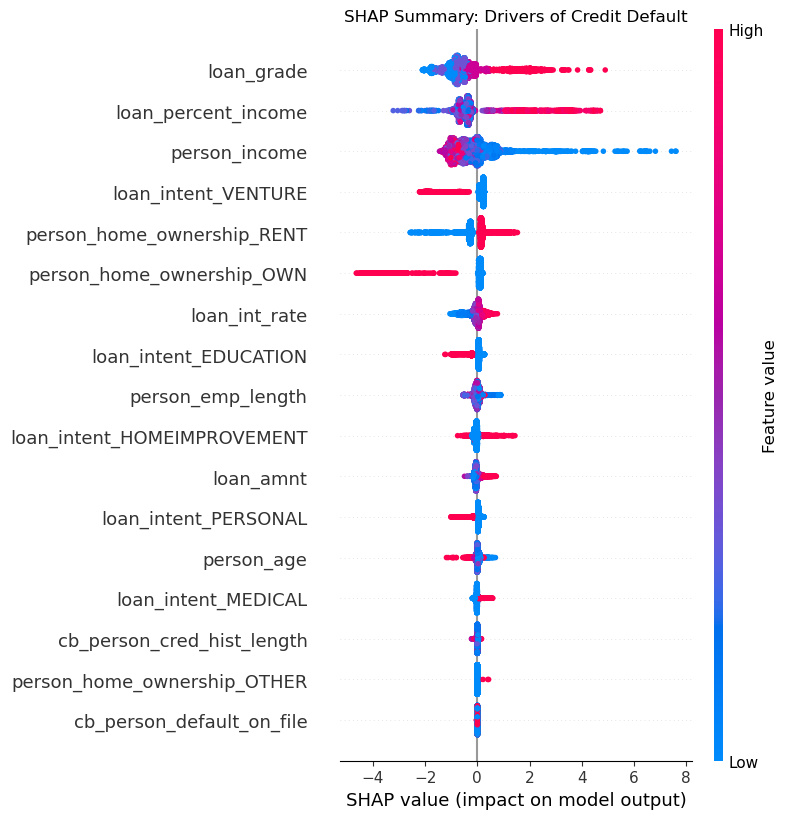

In [9]:
print("\nGenerating SHAP values for model interpretability...")
explainer = shap.TreeExplainer(myXGB)
shap_values = explainer.shap_values(xTest)
plt.title("SHAP Summary: Drivers of Credit Default")
shap.summary_plot(shap_values, xTest)